In [5]:
import pandas as pd

df = pd.read_csv("../Datasets/HAM10000_metadata.csv")

print(df.shape)
print(df.head())

(10015, 7)
     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear


In [6]:
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nDisease Counts:")
print(df["dx"].value_counts())

(10015, 7)

Columns:
Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization'], dtype='str')

Disease Counts:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [7]:
import os

image_dir1 = "../Datasets/HAM10000_images_part_1"
image_dir2 = "../Datasets/HAM10000_images_part_2"

image_paths = {}

for folder in [image_dir1, image_dir2]:
    for img in os.listdir(folder):
        image_id = img.split(".")[0]
        image_paths[image_id] = os.path.join(folder, img)

df["path"] = df["image_id"].map(image_paths)

df[["image_id", "dx", "path"]].head()

,image_id,dx,path
0,ISIC_0027419,bkl,../Datasets/HAM10000_images_part_1\ISIC_002741...
1,ISIC_0025030,bkl,../Datasets/HAM10000_images_part_1\ISIC_002503...
2,ISIC_0026769,bkl,../Datasets/HAM10000_images_part_1\ISIC_002676...
3,ISIC_0025661,bkl,../Datasets/HAM10000_images_part_1\ISIC_002566...
4,ISIC_0031633,bkl,../Datasets/HAM10000_images_part_2\ISIC_003163...


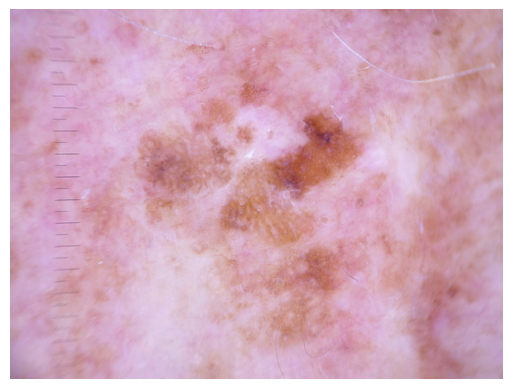

In [9]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(df["path"].iloc[0])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.show()

In [10]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["label"] = encoder.fit_transform(df["dx"])

print(dict(zip(encoder.classes_,
               range(len(encoder.classes_)))))

{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


In [11]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (8012, 9)
Test: (2003, 9)


In [14]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df["label"] = encoder.fit_transform(df["dx"])

print(encoder.classes_)

['akiec' 'bcc' 'bkl' 'df' 'mel' 'nv' 'vasc']


In [15]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

print(train_df.shape)
print(test_df.shape)

(8012, 9)
(2003, 9)


In [16]:
import cv2
import numpy as np

IMG_SIZE = 224

def load_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    return img

In [17]:
sample = load_image(train_df["path"].iloc[0])

print(sample.shape)

(224, 224, 3)


In [18]:
print(train_df.shape)

(8012, 9)


In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col="path",
    y_col="dx",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical"
)

test_generator = test_datagen.flow_from_dataframe(
    test_df,
    x_col="path",
    y_col="dx",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical"
)

Found 8012 validated image filenames belonging to 7 classes.
Found 2003 validated image filenames belonging to 7 classes.


In [20]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)

predictions = Dense(
    7,
    activation="softmax"
)(x)

model = Model(
    inputs=base_model.input,
    outputs=predictions
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [21]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,266,951 (8.65 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [22]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=5
)

Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 569s 2s/step - accuracy: 0.6653 - loss: 1.0214 - val_accuracy: 0.7179 - val_loss: 0.7998
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 499s 2s/step - accuracy: 0.7074 - loss: 0.8279 - val_accuracy: 0.7234 - val_loss: 0.7658
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 487s 2s/step - accuracy: 0.7188 - loss: 0.7984 - val_accuracy: 0.7299 - val_loss: 0.7587
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 919s 4s/step - accuracy: 0.7292 - loss: 0.7670 - val_accuracy: 0.7329 - val_loss: 0.7297
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 478s 2s/step - accuracy: 0.7336 - loss: 0.7518 - val_accuracy: 0.7379 - val_loss: 0.7252


In [23]:
model.save("../Models/skin_model.keras")

In [24]:
import os
print(os.listdir("../Models"))

['skin_model.keras']


In [25]:
loss, acc = model.evaluate(test_generator)

print("Test Accuracy:", acc)

63/63 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.7379 - loss: 0.7252
Test Accuracy: 0.7378931641578674


In [26]:
import numpy as np
import cv2
from tensorflow.keras.models import load_model

model = load_model("../Models/skin_model.keras")

class_names = list(train_generator.class_indices.keys())

def predict_disease(image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (128, 128))
    img = img / 255.0

    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)
    idx = np.argmax(pred)

    return class_names[idx], float(np.max(pred))

In [29]:
# Create a dictionary mapping the dataset shortcuts to clean text and advice
DISEASE_GUIDE = {
    'nv': {
        'name': 'Melanocytic Nevi (Common Mole)',
        'severity': 'Benign (Non-cancerous)',
        'what_it_is': 'A common, harmless skin growth caused by clusters of pigment-producing cells.',
        'what_to_do': 'No medical action is required. Monitor it over time using the ABCDE rules (Asymmetry, Border, Color, Diameter, Evolving).'
    },
    'mel': {
        'name': 'Melanoma',
        'severity': 'Malignant (High Risk / Cancerous)',
        'what_it_is': 'A serious form of skin cancer that begins in cells known as melanocytes.',
        'what_to_do': 'CRITICAL: Please schedule an appointment with a certified dermatologist immediately for a physical evaluation and professional biopsy.'
    },
    'bkl': {
        'name': 'Benign Keratosis-like Lesions',
        'severity': 'Benign (Non-cancerous)',
        'what_it_is': 'Harmless, non-cancerous skin growths that frequently appear as people age (like seborrheic keratoses).',
        'what_to_do': 'Harmless. Treatment is usually only necessary if it becomes irritated by clothing or for cosmetic preferences.'
    },
    'bcc': {
        'name': 'Basal Cell Carcinoma',
        'severity': 'Malignant (Cancerous)',
        'what_it_is': 'A type of skin cancer that grows slowly and rarely spreads, but can damage surrounding tissue.',
        'what_to_do': 'See a doctor or dermatologist soon. They will typically recommend a simple, routine surgical removal.'
    },
    'akiec': {
        'name': 'Actinic Keratoses / Bowen\'s Disease',
        'severity': 'Pre-cancerous',
        'what_it_is': 'Rough, scaly patches caused by years of sun exposure that have a small chance of turning into cancer if left untreated.',
        'what_to_do': 'Consult a dermatologist. They can easily treat this with freezing techniques (cryotherapy) or topical creams.'
    },
    'vasc': {
        'name': 'Vascular Lesions',
        'severity': 'Benign (Non-cancerous)',
        'what_it_is': 'Harmless abnormalities of the blood vessels, such as cherry angiomas or port-wine stains.',
        'what_to_do': 'No treatment is necessary unless you wish to remove them for cosmetic reasons.'
    },
    'df': {
        'name': 'Dermatofibroma',
        'severity': 'Benign (Non-cancerous)',
        'what_it_is': 'Small, firm, harmless bumps that usually develop on the lower legs, often resulting from minor insect bites or injuries.',
        'what_to_do': 'Benign and harmless. Can be safely left alone.'
    }
}

In [34]:
import numpy as np
from PIL import Image

# 1. THE MEDICAL GUIDE DATABASE
DISEASE_GUIDE = {
    'nv': {
        'name': 'Melanocytic Nevi (Common Mole)',
        'severity': 'Benign (Non-cancerous)',
        'what_it_is': 'A common, harmless skin growth caused by clusters of pigment-producing cells.',
        'what_to_do': 'No medical action is required. Monitor it over time using the ABCDE rules.'
    },
    'mel': {
        'name': 'Melanoma',
        'severity': 'Malignant (High Risk / Cancerous)',
        'what_it_is': 'A serious form of skin cancer that begins in cells known as melanocytes.',
        'what_to_do': 'CRITICAL: Please schedule an appointment with a certified dermatologist immediately.'
    },
    'bkl': {
        'name': 'Benign Keratosis-like Lesions',
        'severity': 'Benign (Non-cancerous)',
        'what_it_is': 'Harmless, non-cancerous skin growths that frequently appear as people age.',
        'what_to_do': 'Harmless. Treatment is usually only necessary if it becomes irritated.'
    },
    'bcc': {
        'name': 'Basal Cell Carcinoma',
        'severity': 'Malignant (Cancerous)',
        'what_it_is': 'A type of skin cancer that grows slowly and rarely spreads.',
        'what_to_do': 'See a doctor or dermatologist soon. They will typically recommend removal.'
    },
    'akiec': {
        'name': 'Actinic Keratoses / Bowen\'s Disease',
        'severity': 'Pre-cancerous',
        'what_it_is': 'Rough, scaly patches caused by years of sun exposure.',
        'what_to_do': 'Consult a dermatologist. They can easily treat this with freezing or creams.'
    },
    'vasc': {
        'name': 'Vascular Lesions',
        'severity': 'Benign (Non-cancerous)',
        'what_it_is': 'Harmless abnormalities of the blood vessels, such as cherry angiomas.',
        'what_to_do': 'No treatment is necessary unless for cosmetic reasons.'
    },
    'df': {
        'name': 'Dermatofibroma',
        'severity': 'Benign (Non-cancerous)',
        'what_it_is': 'Small, firm, harmless bumps that usually develop on the lower legs.',
        'what_to_do': 'Benign and harmless. Can be safely left alone.'
    }
}

# 2. THE IMAGE DETECTOR FUNCTION
def analyze_user_skin_image(image_path, trained_model):
    img = Image.open(image_path).convert('RGB')
    
    # FIXED HERE: Resizing to 224x224 to match your model's expected shape!
    img = img.resize((224, 224)) 
    
    img_array = np.array(img).astype('float32') / 255.0  
    img_tensor = np.expand_dims(img_array, axis=0) 
    
    predictions = trained_model.predict(img_tensor)
    highest_confidence_idx = np.argmax(predictions[0])
    confidence_score = predictions[0][highest_confidence_idx] * 100
    
    classes = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
    detected_code = classes[highest_confidence_idx]
    
    info = DISEASE_GUIDE[detected_code]
    
    print("=" * 60)
    print("                DERMASCAN AI DETECTION REPORT            ")
    print("=" * 60)
    print(f"AI Prediction        : {info['name']}")
    print(f"Confidence Score     : {confidence_score:.2f}%")
    print(f"Severity Risk Level  : {info['severity']}")
    print("-" * 60)
    print(f"What it is           : {info['what_it_is']}")
    print(f"Recommended Action   : {info['what_to_do']}")
    print("=" * 60)

# 3. RUNNING THE TEST
# Note: You used 'images.jpeg' in your line 79, making sure it targets that file perfectly
analyze_user_skin_image('images.jpeg', model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
                DERMASCAN AI DETECTION REPORT            
AI Prediction        : Melanocytic Nevi (Common Mole)
Confidence Score     : 62.86%
Severity Risk Level  : Benign (Non-cancerous)
------------------------------------------------------------
What it is           : A common, harmless skin growth caused by clusters of pigment-producing cells.
Recommended Action   : No medical action is required. Monitor it over time using the ABCDE rules.
